# Peanut Stem Rot Incidence Prediction:

This notebook documents a machine learning project aimed at predicting stem rot incidence (`myIncObs`) in peanuts based on environmental and crop-related predictor variables. The analysis covers data loading, visualization, feature engineering, model training (Random Forest, Decision Tree, Linear Regression), hyperparameter tuning, model evaluation, and interpretation.

## Goal

The primary goal is to develop a predictive model that can accurately estimate `myIncObs` to assist in disease management strategies.

## Dataset

The dataset consists of peanut disease assessment data combined with hourly weather data. Predictor variables are derived from environmental conditions (e.g., soil temperature, relative humidity, precipitation, solar radiation, evapotranspiration) and other crop-specific measurements.

## Structure of the Notebook

1.  **Setup and Data Loading**:
2.  **Initial Data Exploration and Visualization**:
3.  **Weather Data Acquisition**: Downloading historical hourly weather data using the Open-Meteo API.
4.  **Feature Engineering**: Calculating relevant environmental predictors from the hourly weather data.
5.  **Correlation Analysis**: Identifying key relationships between predictors and `myIncObs`.
6.  **Model Training and Evaluation**: Training and evaluating different regression models (Random Forest, Decision Tree, Linear Regression).
7.  **Hyperparameter Tuning**: Optimizing the best-performing model.
8.  **Model Interpretation**: Deep diving into the chosen model's insights.

In [2]:
# Set up project directory
import os

# Define the path to the project directory (local)
# This notebook is in: c:\Users\santo\aps-python-workshop-2026\02_disesePrediction\
project_dir = os.path.dirname(os.path.abspath('__file__'))
# Or explicitly:
project_dir = r'c:\Users\santo\aps-python-workshop-2026\02_disesePrediction'

## Load data

In [3]:
import pandas as pd
import os

# Load data from local directory
data_path = os.path.join(project_dir, 'peanut_stemRot_Incidence_mycelia.csv')
df = pd.read_csv(data_path)
display(df.head())

,location,year,variety,inoculum,date,dap_pred,dap,dt,myIncObs,myIncCum,canCover
0,LiveOak,2019,GA06G,Scl1,07/05/2019,0,44,44,0.00,0.00,0
1,LiveOak,2019,GA06G,Scl1,07/10/2019,0,49,5,2.50,2.50,0
2,LiveOak,2019,GA06G,Scl1,07/24/2019,0,63,14,73.75,73.75,1
3,LiveOak,2019,GA06G,Scl1,08/09/2019,0,79,16,62.50,90.00,1
4,LiveOak,2019,GA06G,Scl1,08/22/2019,0,92,13,6.25,90.00,1


## Data visualization

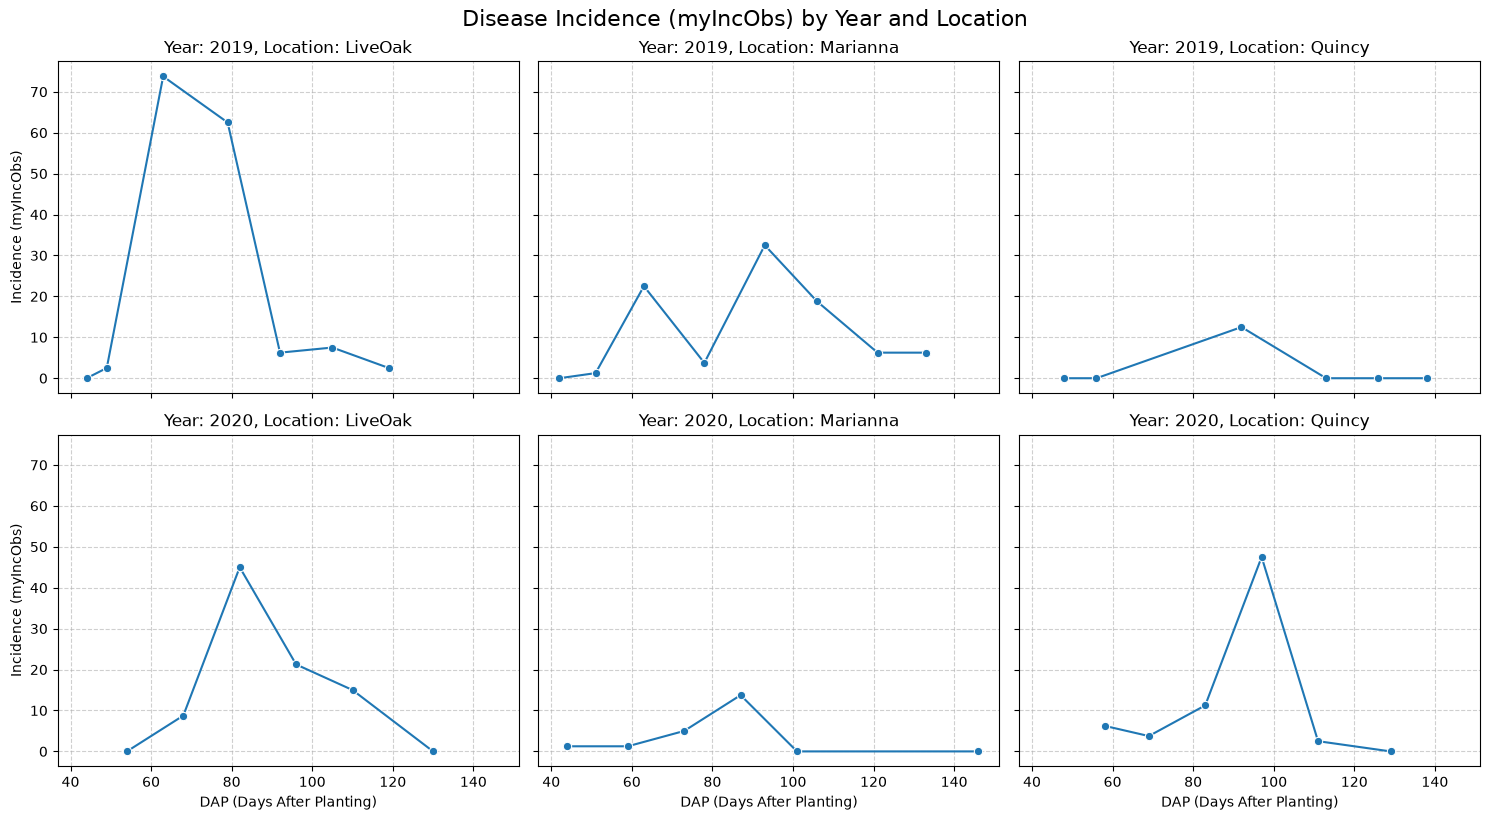

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the date column is in datetime format if needed for other operations
df['date'] = pd.to_datetime(df['date'])

# Get unique years and locations from the new df
unique_years = sorted(df['year'].unique())
unique_locations = sorted(df['location'].unique())

# Define the grid dimensions
num_rows = 2
num_cols = 3

# Create the figure and subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows), sharex=True, sharey=True)

# Flatten axes array for easy iteration, even if it's a 1xN or Nx1 grid
axes = axes.flatten()

plot_idx = 0
# Iterate through years and locations, up to the 2x3 grid limit
for r in range(min(num_rows, len(unique_years))):
    year = unique_years[r]
    for c in range(min(num_cols, len(unique_locations))):
        location = unique_locations[c]

        ax = axes[plot_idx]
        # Filter subset_df using the correct column names 'year' and 'location'
        subset_df = df[(df['year'] == year) & (df['location'] == location)]

        # Plot using 'dap' and 'myIncObs' columns
        sns.lineplot(x='dap', y='myIncObs', data=subset_df, ax=ax, marker='o')

        ax.set_title(f'Year: {year}, Location: {location}')
        ax.set_xlabel('DAP (Days After Planting)')
        ax.set_ylabel('Incidence (myIncObs)')
        ax.grid(True, linestyle='--', alpha=0.6)
        plot_idx += 1


plt.tight_layout()
plt.suptitle('Disease Incidence (myIncObs) by Year and Location', y=1.02, fontsize=16)
plt.show()

## Make maps to understand spatial distribution of the trials


In [10]:
# Add a map to display the spatial distribution of the data

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Your points
data = {'Location': ['Live Oak', 'Quincy', 'Marianna'],
        'latitude': [30.306, 30.54, 30.857],
        'longitude': [-82.901, -84.583, -85.168]}
locations_df = pd.DataFrame(data)
points = gpd.GeoDataFrame(locations_df, geometry=gpd.points_from_xy(locations_df.longitude, locations_df.latitude), crs="EPSG:4326")

# Florida shapefile (US Census state boundaries, filtered to FL)
states = gpd.read_file("https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_state_20m.zip")
florida = states[states['NAME'] == 'Florida']

# Plot
fig, ax = plt.subplots(figsize=(8, 8))
florida.plot(ax=ax, color='whitesmoke', edgecolor='black')
points.plot(ax=ax, color='red', markersize=60)

for x, y, label in zip(locations_df.longitude, locations_df.latitude, locations_df.Location):
    ax.annotate(label, xy=(x, y), xytext=(5, 5), textcoords="offset points", fontsize=9)

ax.set_title("Field trial locations in Florida")
plt.show()

ImportError: The 'read_file' function requires the 'pyogrio' or 'fiona' package, but neither is installed or imports correctly.
Importing pyogrio resulted in: DLL load failed while importing _vsi: The specified procedure could not be found.
Importing fiona resulted in: No module named 'fiona'

In [ ]:
print(df.columns)

# Fetching the weather data - OPEN MATEO

# Save the hourly data

In [ ]:
import requests
import pandas as pd
import os # Import os module

# Set this to wherever you want the files saved in your Drive
# Use the project_dir defined earlier for consistency
save_folder = project_dir # Assuming project_dir is defined in a previous cell

# STEP 1: List your locations (name, latitude, longitude)

locations = {
    "Live Oak": (30.306, -82.901),
    "Quincy": (30.540, -84.583),
    "Marianna": (30.857, -85.168),
}

# ---------------------------------------------------------
# STEP 2: List the years you want data for
# ---------------------------------------------------------
years = [2019, 2020] # Changed years to match previous requests

# ---------------------------------------------------------
# STEP 3: Set the growing season start and end (month-day)
# ---------------------------------------------------------
start_month_day = "05-01"   # May 1
end_month_day = "10-31"     # October 31

# ---------------------------------------------------------
# STEP 4: Choose which weather variables to download
# These variables are needed for the predictor calculation script.
# ---------------------------------------------------------
weather_variables = "soil_temperature_0_to_7cm,relative_humidity_2m,precipitation,et0_fao_evapotranspiration,shortwave_radiation"


# ---------------------------------------------------------
# This function downloads weather for ONE location and ONE date range
# ---------------------------------------------------------
def download_weather(latitude, longitude, start_date, end_date):

    url = "https://archive-api.open-meteo.com/v1/archive"

    # These are the settings we send to the weather website
    settings = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": weather_variables,
        "temperature_unit": "fahrenheit",
        "timezone": "auto",
    }

    # Ask the website for the data
    response = requests.get(url, params=settings)
    response.raise_for_status() # Add this to catch HTTP errors like 404, 500
    data = response.json()

    # Turn the hourly data into a table (DataFrame)
    weather_table = pd.DataFrame(data["hourly"])
    weather_table["time"] = pd.to_datetime(weather_table["time"])
    weather_table = weather_table.rename(columns={
        "time": "datetime",
        "soil_temperature_0_to_7cm": "soil_temperature",
        "relative_humidity_2m": "relative_humidity",
        "et0_fao_evapotranspiration": "evapotranspiration",
        "shortwave_radiation": "solar_radiation"
    })

    return weather_table


# ---------------------------------------------------------
# STEP 5: Loop through every location and every year,
# download the data, and save each one as its own CSV file
# ---------------------------------------------------------

# Ensure the save_folder exists. If not, create it.
os.makedirs(save_folder, exist_ok=True)

for location_name in locations:

    latitude = locations[location_name][0]
    longitude = locations[location_name][1]

    for year in years:

        start_date = str(year) + "-" + start_month_day
        end_date = str(year) + "-" + end_month_day

        print("Downloading:", location_name, year)

        try:
            weather_table = download_weather(latitude, longitude, start_date, end_date)

            # Build a simple file name, like "Live Oak_2019.csv", and save in save_folder
            # Use os.path.join for robust path handling
            file_name = os.path.join(save_folder, f"{location_name.replace(' ', '_')}_{year}.csv")

            weather_table.to_csv(file_name, index=False)

            print("Saved:", file_name)
        except requests.exceptions.RequestException as e:
            print(f"Error downloading data for {location_name}, {year}: {e}")
        except Exception as e:
            print(f"An unexpected error occurred for {location_name}, {year}: {e}")

print("Done! Check your Google Drive folder for the CSV files.")

Downloading: Live Oak 2019
Saved: /content/drive/MyDrive/Colab Notebooks/stemRot_APS_python/Live_Oak_2019.csv
Downloading: Live Oak 2020
Saved: /content/drive/MyDrive/Colab Notebooks/stemRot_APS_python/Live_Oak_2020.csv
Downloading: Quincy 2019
Saved: /content/drive/MyDrive/Colab Notebooks/stemRot_APS_python/Quincy_2019.csv
Downloading: Quincy 2020
Saved: /content/drive/MyDrive/Colab Notebooks/stemRot_APS_python/Quincy_2020.csv
Downloading: Marianna 2019
Saved: /content/drive/MyDrive/Colab Notebooks/stemRot_APS_python/Marianna_2019.csv
Downloading: Marianna 2020
Saved: /content/drive/MyDrive/Colab Notebooks/stemRot_APS_python/Marianna_2020.csv
Done! Check your Google Drive folder for the CSV files.


# Predictor calculation (Feature engineering)

In [ ]:
import pandas as pd
import os

# ---------------------------------------------------------
# STEP 1: Load your disease assessment data
# ---------------------------------------------------------
disease_data = df

# Keep the original "date" column exactly as it is (e.g. "07/05/2019")
# and make a separate parsed version just for doing date math
disease_data["assessment_date"] = pd.to_datetime(disease_data["date"])

# ---------------------------------------------------------
# STEP 2: Tell the script where each site-year's weather file is.
# These must be the hourly weather CSVs you already downloaded
# (one file per location + year), with columns:
#   datetime, soil_temperature, relative_humidity,
#   precipitation, evapotranspiration, solar_radiation
#
# NOTE: your original weather-download script pulled
# temperature_2m / relative_humidity_2m / precipitation /
# wind_speed_10m. For this step you need different variables
# from Open-Meteo instead: soil_temperature_0_to_7cm,
# relative_humidity_2m, precipitation, et0_fao_evapotranspiration,
# and shortwave_radiation. Update the "hourly" variable list in
# your download script to include those, then rename the columns
# to match the names below before running this script.
# ---------------------------------------------------------
# Use the previously defined project_dir to construct full paths
# The location names in the disease data are 'LiveOak', 'Quincy', 'Marianna'
# The saved weather files use 'Live_Oak', 'Quincy', 'Marianna' (note underscore for Live Oak)
weather_files = {
    ("LiveOak", 2019): os.path.join(project_dir, "Live_Oak_2019.csv"),
    ("LiveOak", 2020): os.path.join(project_dir, "Live_Oak_2020.csv"),
    ("Marianna", 2019): os.path.join(project_dir, "Marianna_2019.csv"),
    ("Marianna", 2020): os.path.join(project_dir, "Marianna_2020.csv"),
    ("Quincy", 2019): os.path.join(project_dir, "Quincy_2019.csv"),
    ("Quincy", 2020): os.path.join(project_dir, "Quincy_2020.csv")
}

# Keep loaded weather files here so we don't reload the same
# file over and over for every row
loaded_weather = {}


# ---------------------------------------------------------
# STEP 3: This function calculates all the predictors for
# ONE window of hourly weather data (a small slice of a
# site-year's weather file)
# ---------------------------------------------------------
def calculate_predictors(weather_window):

    # First, group the hourly data by day to get daily
    # mean / min / max soil temperature (ST) and daily mean RH
    weather_window = weather_window.copy()
    weather_window["day"] = weather_window["datetime"].dt.date

    daily = weather_window.groupby("day").agg(
        ST_mean=("soil_temperature", "mean"),
        ST_min=("soil_temperature", "min"),
        ST_max=("soil_temperature", "max"),
        RH_mean=("relative_humidity", "mean"),
        precip_sum=("precipitation", "sum"),
        et_sum=("evapotranspiration", "sum")
    )

    predictors = {}

    # --- Soil temperature (ST) predictors ---
    predictors["avgST"] = daily["ST_mean"].mean()
    predictors["avgSTmin"] = daily["ST_min"].mean()
    predictors["avgSTmx"] = daily["ST_max"].mean()

    st = weather_window["soil_temperature"]
    predictors["nHrST25.30"] = ((st > 25) & (st < 30)).sum()
    predictors["nHrST25.35"] = ((st > 25) & (st < 35)).sum()
    predictors["nHrSTa30"] = (st > 30).sum()

    # --- Relative humidity (RH) predictors ---
    predictors["avgRH"] = daily["RH_mean"].mean()

    rh = weather_window["relative_humidity"]
    predictors["nHrRHa80"] = (rh > 80).sum()
    predictors["nHrRHa85"] = (rh > 85).sum()
    predictors["nHrRHa90"] = (rh > 90).sum()

    # --- Interaction predictors (ST and RH together) ---
    predictors["nHrRHa80ST25.30"] = ((rh > 80) & (st > 25) & (st < 30)).sum()
    predictors["nHrRHa85ST25.30"] = ((rh > 85) & (st > 25) & (st < 30)).sum()
    predictors["nHrRHa90ST25.30"] = ((rh > 90) & (st > 25) & (st < 30)).sum()

    predictors["avgHTR"] = (daily["RH_mean"] / daily["ST_mean"]).mean()

    # --- Precipitation predictors ---
    predictors["avgDRnI"] = daily["precip_sum"].mean()
    predictors["cumDRnI"] = daily["precip_sum"].sum()

    # --- Evapotranspiration predictors ---
    predictors["avgETin"] = daily["et_sum"].mean()
    predictors["cumETin"] = daily["et_sum"].sum()

    # --- Solar radiation predictor ---
    predictors["cumSRad"] = weather_window["solar_radiation"].sum()

    return predictors


# ---------------------------------------------------------
# STEP 4: Loop through every disease assessment row,
# build its window, calculate predictors, and save the result
# ---------------------------------------------------------
all_predictor_rows = []

for row_number in range(len(disease_data)):

    row = disease_data.iloc[row_number]

    location = row["location"]
    year = row["year"]
    assessment_date = row["assessment_date"]

    # Build the 14-day window: 19 days before to 5 days before
    window_start = assessment_date - pd.Timedelta(days=19)
    window_end = assessment_date - pd.Timedelta(days=5)

    # Load the weather file for this site-year (only once, then reuse)
    site_year_key = (location, year)

    if site_year_key not in loaded_weather:
        file_name = weather_files[site_year_key]
        weather = pd.read_csv(file_name)
        weather["datetime"] = pd.to_datetime(weather["datetime"])
        loaded_weather[site_year_key] = weather

    weather = loaded_weather[site_year_key]

    # Keep only the hourly rows that fall inside this window
    in_window = (weather["datetime"] >= window_start) & (weather["datetime"] <= window_end)
    weather_window = weather[in_window]

    # Calculate the predictors for this window
    predictors = calculate_predictors(weather_window)

    all_predictor_rows.append(predictors)

    print("Calculated predictors for:", location, year, row["date"])

# ---------------------------------------------------------
# STEP 5: Attach the predictor columns onto the disease data,
# row by row (row order matches exactly, so no merge is needed),
# then arrange columns to match your project's predictor table
# ---------------------------------------------------------
predictor_table = pd.DataFrame(all_predictor_rows)

final_table = pd.concat([disease_data, predictor_table], axis=1)

# Drop the helper column we added just for date math
final_table = final_table.drop(columns=["assessment_date"])

# Put the columns in the same order as your project's predictor table.
# (GWET and leaf-number columns aren't included here since they come
# from separate data sources / calculations, not from this script.)
column_order = [
    "location", "year", "variety", "inoculum", "date",
    "dap_pred", "dap", "dt", "myIncObs", "myIncCum", "canCover",
    "cumETin", "avgETin", "cumSRad", "avgHTR",
    "nHrST25.35", "nHrST25.30", "nHrSTa30",
    "nHrRHa80", "nHrRHa85", "nHrRHa90",
    "nHrRHa80ST25.30", "nHrRHa85ST25.30", "nHrRHa90ST25.30",
    "cumDRnI", "avgDRnI",
    "avgRH", "avgST", "avgSTmin", "avgSTmx"
]
final_table = final_table[column_order]

# Save the combined file to the project_dir
final_table.to_csv(os.path.join(project_dir, "stemrot_disease_and_predictors.csv"), index=False)

print("\nDone! Saved combined file: stemrot_disease_and_predictors.csv")

Calculated predictors for: LiveOak 2019 2019-07-05 00:00:00
Calculated predictors for: LiveOak 2019 2019-07-10 00:00:00
Calculated predictors for: LiveOak 2019 2019-07-24 00:00:00
Calculated predictors for: LiveOak 2019 2019-08-09 00:00:00
Calculated predictors for: LiveOak 2019 2019-08-22 00:00:00
Calculated predictors for: LiveOak 2019 2019-09-04 00:00:00
Calculated predictors for: LiveOak 2019 2019-09-18 00:00:00
Calculated predictors for: LiveOak 2020 2020-07-08 00:00:00
Calculated predictors for: LiveOak 2020 2020-07-22 00:00:00
Calculated predictors for: LiveOak 2020 2020-08-05 00:00:00
Calculated predictors for: LiveOak 2020 2020-08-19 00:00:00
Calculated predictors for: LiveOak 2020 2020-09-02 00:00:00
Calculated predictors for: LiveOak 2020 2020-09-22 00:00:00
Calculated predictors for: Marianna 2019 2019-07-03 00:00:00
Calculated predictors for: Marianna 2019 2019-07-12 00:00:00
Calculated predictors for: Marianna 2019 2019-07-24 00:00:00
Calculated predictors for: Marianna 2

# This Python code block will:
1.  Load the `stemrot_disease_and_predictors.csv` file into a pandas DataFrame.
2.  Identify the predictor variables and the target variable (`myIncObs`).
3.  Calculate the Spearman rank correlation coefficients between each predictor and `myIncObs` using `scipy.stats.spearmanr`.
4.  Display the results.

In [6]:
import pandas as pd
import os
from scipy.stats import spearmanr

# Set the path to your project directory
project_dir = '/content/drive/MyDrive/Colab Notebooks/stemRot_APS_python'
file_path = os.path.join(project_dir, 'stemrot_disease_and_predictors.csv')

# Load the dataset
data_df = pd.read_csv(file_path)

# Display the first few rows and info to verify loading
print("First 5 rows of the dataset:")
display(data_df.head())
print("\nData Info:")
data_df.info()

# Identify predictor columns and the target variable 'myIncObs'
# Using the same list of predictor columns as in the R script
predictor_cols = [
    "cumETin", "avgETin", "cumSRad", "avgHTR",
    "nHrST25.35", "nHrST25.30", "nHrSTa30",
    "nHrRHa80", "nHrRHa85", "nHrRHa90",
    "nHrRHa80ST25.30", "nHrRHa85ST25.30", "nHrRHa90ST25.30",
    "cumDRnI", "avgDRnI",
    "avgRH", "avgST", "avgSTmin", "avgSTmx"
]

target_col = "myIncObs"

# Prepare the data for correlation calculation
# Select only the relevant columns and drop rows with any NaN values
# This is important for correlation calculations
correlation_data = data_df[predictor_cols + [target_col]].dropna()

# Initialize a dictionary to store correlations
spearman_correlations = {}

# Calculate Spearman rank correlation for each predictor with 'myIncObs'
for col in predictor_cols:
    if col in correlation_data.columns and target_col in correlation_data.columns:
        # spearmanr returns (correlation, p-value)
        corr, _ = spearmanr(correlation_data[col], correlation_data[target_col])
        spearman_correlations[col] = corr

# Convert to a pandas Series for easy sorting and display
correlations_series = pd.Series(spearman_correlations)

# Display the correlations, sorted by absolute value
print("\nSpearman Rank Correlation Coefficients with myIncObs (sorted by value):\n")
display(correlations_series.sort_values(ascending=False))


First 5 rows of the dataset:


,location,year,variety,inoculum,date,dap_pred,dap,dt,myIncObs,myIncCum,...,nHrRHa90,nHrRHa80ST25.30,nHrRHa85ST25.30,nHrRHa90ST25.30,cumDRnI,avgDRnI,avgRH,avgST,avgSTmin,avgSTmx
0,LiveOak,2019,GA06G,Scl1,2019-07-05,0,44,44,0.00,0.00,...,96,0,0,0,43.1,2.873333,75.711111,82.752778,76.433333,90.173333
1,LiveOak,2019,GA06G,Scl1,2019-07-10,0,49,5,2.50,2.50,...,65,0,0,0,37.7,2.513333,70.569444,85.450278,77.780000,95.046667
2,LiveOak,2019,GA06G,Scl1,2019-07-24,0,63,14,73.75,73.75,...,121,0,0,0,83.6,5.573333,80.058333,82.208333,76.653333,88.906667
3,LiveOak,2019,GA06G,Scl1,2019-08-09,0,79,16,62.50,90.00,...,104,0,0,0,48.1,3.206667,76.322222,80.960556,74.553333,88.233333
4,LiveOak,2019,GA06G,Scl1,2019-08-22,0,92,13,6.25,90.00,...,118,0,0,0,86.0,5.733333,78.780556,84.067222,77.760000,92.386667



Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 30 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   location         39 non-null     object 
 1   year             39 non-null     int64  
 2   variety          39 non-null     object 
 3   inoculum         39 non-null     object 
 4   date             39 non-null     object 
 5   dap_pred         39 non-null     int64  
 6   dap              39 non-null     int64  
 7   dt               39 non-null     int64  
 8   myIncObs         39 non-null     float64
 9   myIncCum         39 non-null     float64
 10  canCover         39 non-null     int64  
 11  cumETin          39 non-null     float64
 12  avgETin          39 non-null     float64
 13  cumSRad          39 non-null     float64
 14  avgHTR           39 non-null     float64
 15  nHrST25.35       39 non-null     int64  
 16  nHrST25.30       39 non-null     int64  
 17  nHrSTa

/tmp/ipykernel_1757/2474013986.py:43: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(correlation_data[col], correlation_data[target_col])


,0
avgDRnI,0.317387
cumDRnI,0.317387
avgSTmx,0.248604
avgST,0.246548
nHrRHa80,0.242600
nHrRHa85,0.240298
avgSTmin,0.225328
avgRH,0.190617
nHrRHa90,0.177296
avgHTR,0.059632


# **Correlation analysis**
  - select the candidate predictors
  - select the best window
## Spearmank rank correlation vs Pearson's correlation bold text

          predictor  pearson_r  pearson_p  spearman_rho  spearman_p
14  nHrRHa90ST25.30   0.443436   0.004692      0.551040    0.000278
13  nHrRHa85ST25.30   0.411088   0.009328      0.550305    0.000284
12  nHrRHa80ST25.30   0.380009   0.017022      0.544459    0.000339
7        nHrST25.30   0.322271   0.045410      0.420710    0.007656
6        nHrST25.35   0.277347   0.087378      0.341378    0.033428
9          nHrRHa80   0.254523   0.117897      0.322576    0.045194
1          canCover   0.307996   0.056454      0.316650    0.049529
10         nHrRHa85   0.239759   0.141529      0.276027    0.088957
11         nHrRHa90   0.229546   0.159806      0.274185    0.091196
18            avgST   0.246528   0.130295      0.256007    0.115698
20          avgSTmx   0.245636   0.131737      0.250044    0.124730
19         avgSTmin   0.247257   0.129127      0.249118    0.126177
17            avgRH   0.246085   0.131010      0.247884    0.128127
8          nHrSTa30   0.175953   0.283962      0

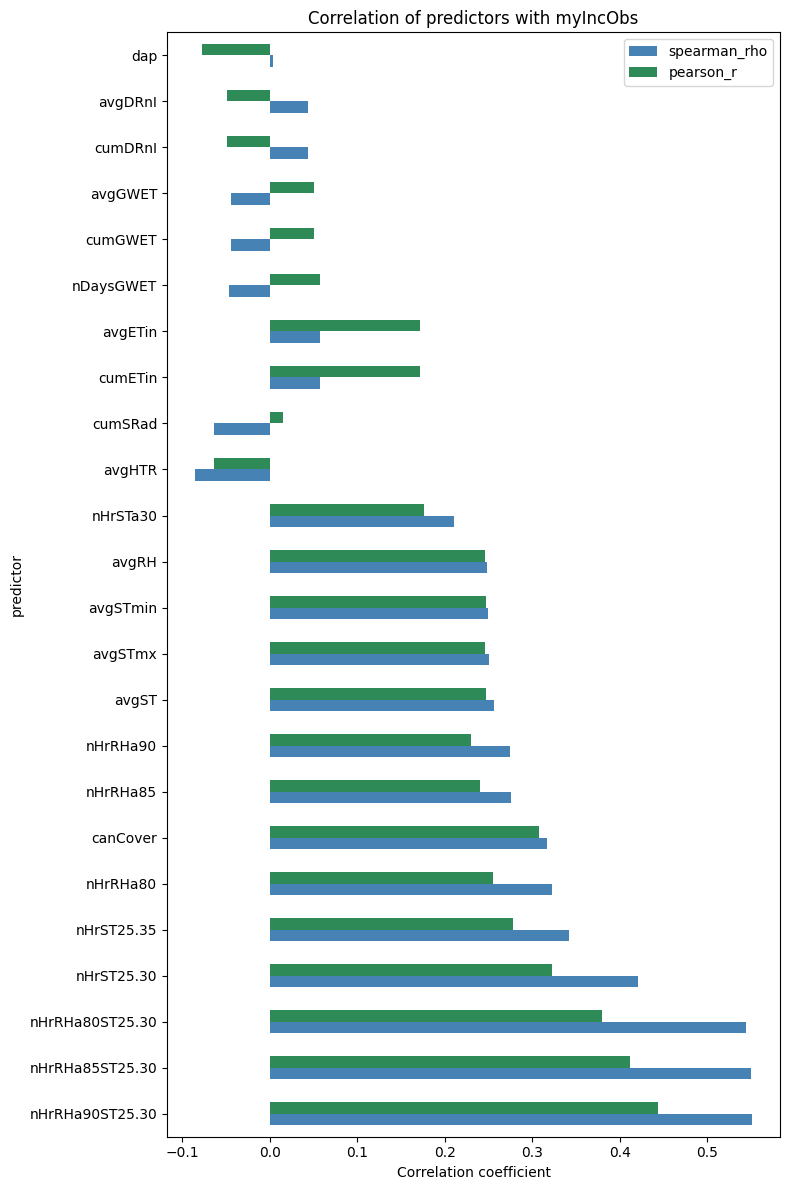

In [23]:
"""
Correlation analysis: predictors vs. stem rot mycelial incidence (myIncObs)

For every predictor column, this script calculates:
  - Pearson's correlation coefficient (r)         -> measures linear relationships
  - Spearman's rank correlation coefficient (rho)  -> measures monotonic relationships

This matches the analysis shown in Figure 5 of the paper.

Needs: pip install pandas scipy matplotlib
"""

import os
import pandas as pd
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# STEP 1: Load your predictor + disease data table
#
# "project_dir" should already be set from an earlier cell
# (the folder in your Google Drive where your files live)
# ---------------------------------------------------------
file_path = os.path.join(project_dir, "srNpredictorsW14_19_5.csv")
data = pd.read_csv(file_path)

# ---------------------------------------------------------
# STEP 2: Set the response variable (the disease measurement
# we want to correlate everything against)
# ---------------------------------------------------------
response_column = "myIncObs"

# ---------------------------------------------------------
# STEP 3: List the columns that are NOT predictors
# (identifiers, dates, and other disease response columns).
# Everything else in the table is treated as a predictor.
# ---------------------------------------------------------
non_predictor_columns = [
    "location", "year", "variety", "inoculum", "date",
    "dap_pred", "dt", "myIncObs", "myIncCum"
]

predictor_columns = []

for column_name in data.columns:
    if column_name not in non_predictor_columns:
        predictor_columns.append(column_name)


# ---------------------------------------------------------
# This function calculates Pearson and Spearman correlation
# for ONE predictor against the response column.
#
# If a column has no variation (every value is the same),
# correlation cannot be calculated, so we return blank (NaN)
# values instead of letting the script crash.
# ---------------------------------------------------------
def calculate_correlation(predictor_values, response_values):

    predictor_has_variation = predictor_values.nunique() > 1
    response_has_variation = response_values.nunique() > 1

    if predictor_has_variation and response_has_variation:
        pearson_r, pearson_p = pearsonr(predictor_values, response_values)
        spearman_rho, spearman_p = spearmanr(predictor_values, response_values)
    else:
        pearson_r, pearson_p = float("nan"), float("nan")
        spearman_rho, spearman_p = float("nan"), float("nan")

    return pearson_r, pearson_p, spearman_rho, spearman_p


# ---------------------------------------------------------
# STEP 4: Loop through each predictor and calculate both
# correlation coefficients against myIncObs
# ---------------------------------------------------------
results = []

for predictor in predictor_columns:

    pearson_r, pearson_p, spearman_rho, spearman_p = calculate_correlation(
        data[predictor], data[response_column]
    )

    results.append({
        "predictor": predictor,
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "spearman_rho": spearman_rho,
        "spearman_p": spearman_p,
    })

# ---------------------------------------------------------
# STEP 5: Put the results into a table, sorted so the
# strongest relationships appear first (regardless of
# whether they are positive or negative)
# ---------------------------------------------------------
results_table = pd.DataFrame(results)

results_table["strength"] = results_table["spearman_rho"].abs()
results_table = results_table.sort_values("strength", ascending=False)
results_table = results_table.drop(columns=["strength"])

print(results_table)

results_path = os.path.join(project_dir, "predictor_correlation_results.csv")
results_table.to_csv(results_path, index=False)
print("\nSaved:", results_path)

# ---------------------------------------------------------
# STEP 6: Make a simple bar chart comparing Pearson and
# Spearman coefficients for each predictor (like Figure 5)
#
# Predictors with missing (NaN) values are left out of the
# chart since they have nothing to plot.
# ---------------------------------------------------------
chart_data = results_table.dropna(subset=["pearson_r", "spearman_rho"])
chart_data = chart_data.set_index("predictor")

if len(chart_data) == 0:
    print("No valid correlation results to plot.")
else:
    chart_height = max(10, len(chart_data) * 0.5)

    chart_data[["spearman_rho", "pearson_r"]].plot(
        kind="barh", figsize=(8, chart_height), color=["steelblue", "seagreen"]
    )
    plt.xlabel("Correlation coefficient")
    plt.title("Correlation of predictors with " + response_column)
    plt.tight_layout()

    chart_path = os.path.join(project_dir, "predictor_correlation_chart.png")
    plt.savefig(chart_path)
    print("Saved chart:", chart_path)

# Model fitting
# 1. Randon forrest
# 2. Cross validation (leave one one out, elastic net)


In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Ensure 'data' DataFrame is available from previous cells, otherwise load it.
# In this context, 'data' should already be loaded from 'srNpredictorsW14_19_5.csv'
# as per cell n7Nm-9R_bEs7.

# Define features (X) and target (y)
# Use the 'predictor_columns' and 'response_column' determined in the correlation analysis
# (from cell n7Nm-9R_bEs7, assuming it has been run and these variables are in scope)

# If 'predictor_columns' or 'response_column' are not in scope, re-define them here
# For robustness, we will redefine them based on the context's variable state.
predictor_columns = [
    "cumETin", "avgETin", "cumSRad", "avgHTR", "nHrST25.35", "nHrST25.30",
    "nHrSTa30", "nHrRHa80", "nHrRHa85", "nHrRHa90", "nHrRHa80ST25.30",
    "nHrRHa85ST25.30", "nHrRHa90ST25.30", "cumDRnI", "avgDRnI", "avgRH",
    "avgST", "avgSTmin", "avgSTmx", "avgGWET", "cumGWET", "nDaysGWET"
]
response_column = "myIncObs"

# Drop rows where the target variable is NaN, as RandomForestRegressor cannot handle them
model_data = data.dropna(subset=[response_column])

X = model_data[predictor_columns]
y = model_data[response_column]

# Handle potential NaN values in features after subsetting data for model
# Fill NaN values in features with the mean of their respective columns
X = X.fillna(X.mean())

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest Regressor model
# Using random_state for reproducibility
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Random Forest Model Performance:")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")


Random Forest Model Performance:
Mean Squared Error: 293.95
R-squared: -0.27


### Residual Plot
A residual plot helps to identify if the model's errors are randomly distributed or if there's a pattern, which could indicate that the model is not capturing all the information in the data.

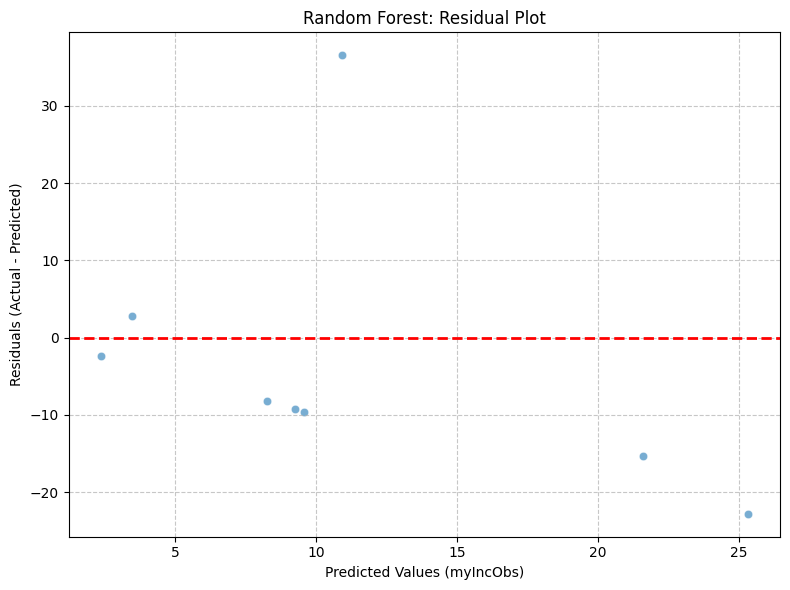

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', lw=2) # Zero residual line
plt.xlabel('Predicted Values (myIncObs)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Random Forest: Residual Plot')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Model Performance with Leave-One-Out Cross-Validation (LOOCV)
Given the small dataset size, Leave-One-Out Cross-Validation (LOOCV) provides a thorough evaluation by using almost all data for training in each iteration. We will evaluate the same Random Forest model using this strategy.

In [25]:
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# Re-initialize the Random Forest Regressor with the same parameters
rf_model_cv = RandomForestRegressor(n_estimators=100, random_state=42)

# Set up Leave-One-Out Cross-Validation
loo = LeaveOneOut()

# Perform cross-validation for R-squared
r2_scores_cv = cross_val_score(rf_model_cv, X, y, cv=loo, scoring='r2', n_jobs=-1)

# Perform cross-validation for Mean Squared Error
mse_scores_cv = -cross_val_score(rf_model_cv, X, y, cv=loo, scoring='neg_mean_squared_error', n_jobs=-1) # Use negative MSE because cross_val_score minimizes

print(f"LOOCV R-squared Scores: {r2_scores_cv}")
print(f"Average LOOCV R-squared: {np.mean(r2_scores_cv):.2f} (Std: {np.std(r2_scores_cv):.2f})")
print(f"\nLOOCV Mean Squared Error Scores: {mse_scores_cv}")
print(f"Average LOOCV Mean Squared Error: {np.mean(mse_scores_cv):.2f} (Std: {np.std(mse_scores_cv):.2f})")


LOOCV R-squared Scores: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan]
Average LOOCV R-squared: nan (Std: nan)

LOOCV Mean Squared Error Scores: [4.05015625e+00 2.51251563e+01 3.80072250e+03 2.55277562e+03
 3.19225000e+01 9.03002500e+02 2.27255625e+02 5.32900000e+01
 2.69101562e+01 5.23265625e+02 7.94326563e+01 1.17306250e+01
 3.51093906e+02 8.05140625e+00 8.05140625e+00 1.48225000e+01
 1.17451406e+02 5.47600000e+01 5.92900000e+01 3.41787656e+02
 4.95264062e+01 4.48900000e+01 1.14921000e+03 6.23126406e+02
 3.30625000e+01 6.51525625e+02 3.19225000e+01 3.33062500e+00
 1.04814062e+01 7.96556250e+01 4.55625000e+01 2.22076563e+01
 2.56000000e+00 2.42556250e+01 3.46890625e+00 7.98789062e+01
 1.42411891e+03 9.80100000e+01 4.59006250e+01]
Average LOOCV Mean Squared Error: 349.17 (Std: 747.93)


The cross-validation results reinforce the earlier observation: the model is performing very poorly. The average R-squared is still negative, indicating that even with LOOCV, the model cannot explain the variance in the target variable effectively. This confirms that the issue is not just due to a particular train-test split, but is inherent to the model's ability to fit this data with the current features.

### Decision Tree Regressor Model
Let's fit a simpler model, the Decision Tree Regressor, and evaluate its performance.

In [27]:
from sklearn.tree import DecisionTreeRegressor

# Initialize and train the Decision Tree Regressor model
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dt = dt_model.predict(X_test)

# Evaluate the model
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print(f"Decision Tree Model Performance:")
print(f"Mean Squared Error: {mse_dt:.2f}")
print(f"R-squared: {r2_dt:.2f}")


Decision Tree Model Performance:
Mean Squared Error: 92.97
R-squared: 0.60


### Linear Regression Model
Now, let's fit a Linear Regression model, which is one of the simplest predictive models.

In [28]:
from sklearn.linear_model import LinearRegression

# Initialize and train the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lr = lr_model.predict(X_test)

# Evaluate the model
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression Model Performance:")
print(f"Mean Squared Error: {mse_lr:.2f}")
print(f"R-squared: {r2_lr:.2f}")


Linear Regression Model Performance:
Mean Squared Error: 3122.02
R-squared: -12.48


### Comparison of Model Performances
Let's compare the R-squared and Mean Squared Error for the Random Forest, Decision Tree, and Linear Regression models.

In [30]:
print("--- Model Performance Summary ---")
print(f"Random Forest: R-squared = {r2:.2f}, MSE = {mse:.2f}")
print(f"Decision Tree: R-squared = {r2_dt:.2f}, MSE = {mse_dt:.2f}")
print(f"Linear Regression: R-squared = {r2_lr:.2f}, MSE = {mse_lr:.2f}")


--- Model Performance Summary ---
Random Forest: R-squared = -0.27, MSE = 293.95
Decision Tree: R-squared = 0.60, MSE = 92.97
Linear Regression: R-squared = -12.48, MSE = 3122.02


### Decision Tree Model Feature Importance
Let's examine the feature importances for the Decision Tree model to see which predictors were most influential for its predictions.

/tmp/ipykernel_1757/4075614590.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_importances_dt.values, y=sorted_importances_dt.index, palette='viridis')


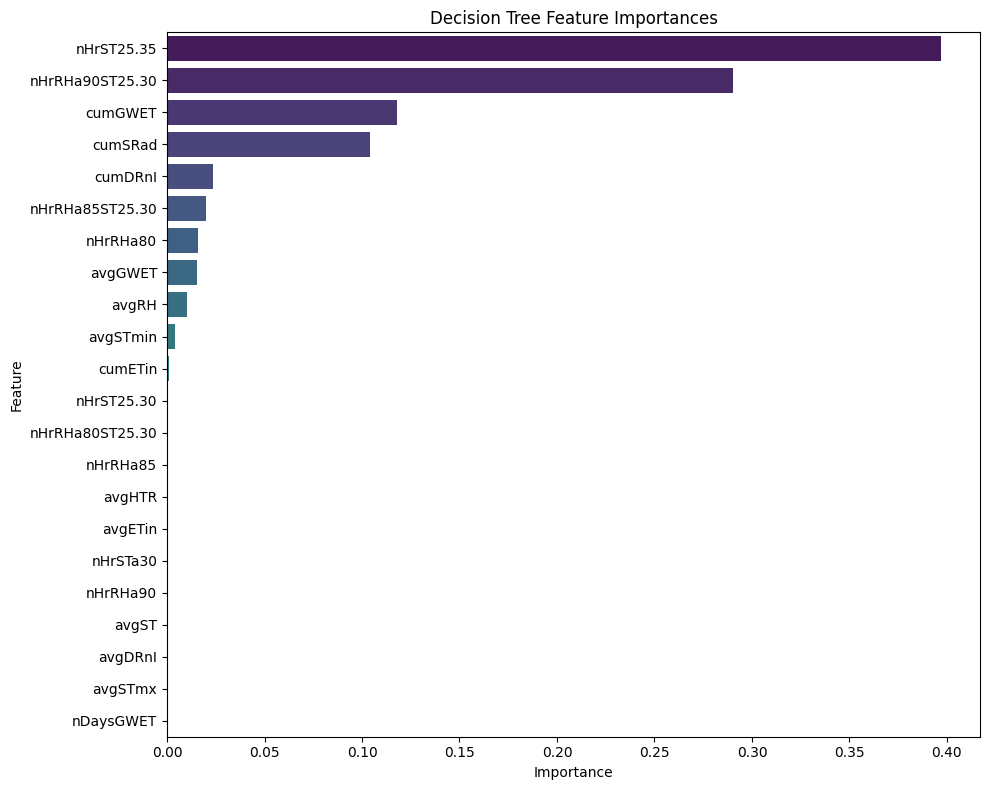

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get feature importances from the Decision Tree model
feature_importances_dt = pd.Series(dt_model.feature_importances_, index=X.columns)

# Sort them in descending order
sorted_importances_dt = feature_importances_dt.sort_values(ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 8))
sns.barplot(x=sorted_importances_dt.values, y=sorted_importances_dt.index, palette='viridis')
plt.title('Decision Tree Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


### Hyperparameter Tuning for Decision Tree Regressor
We will use `GridSearchCV` to systematically search for the best combination of hyperparameters for our Decision Tree model. This helps in optimizing model performance and preventing overfitting.

In [35]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Define the parameter grid to search
param_grid = {
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['squared_error', 'friedman_mse', 'absolute_error', 'poisson']
}

# Initialize a Decision Tree Regressor
dt_tuned = DecisionTreeRegressor(random_state=42)

# Initialize GridSearchCV with 5-fold Cross-Validation
# scoring='r2' to optimize for R-squared
# n_jobs=-1 to use all available processors
grid_search = GridSearchCV(
    estimator=dt_tuned,
    param_grid=param_grid,
    cv=5, # Changed to 5-fold CV
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best Hyperparameters: {best_params}")
print(f"Best R-squared from Grid Search (on training data): {best_score:.2f}")

# Train a new Decision Tree model with the best parameters
best_dt_model = DecisionTreeRegressor(**best_params, random_state=42)
best_dt_model.fit(X_train, y_train)

# Make predictions on the test set using the best model
y_pred_best_dt = best_dt_model.predict(X_test)

# Evaluate the best model on the test set
mse_best_dt = mean_squared_error(y_test, y_pred_best_dt)
r2_best_dt = r2_score(y_test, y_pred_best_dt)

print(f"\nBest Decision Tree Model Performance on Test Set:")
print(f"Mean Squared Error: {mse_best_dt:.2f}")
print(f"R-squared: {r2_best_dt:.2f}")

Fitting 5 folds for each of 180 candidates, totalling 900 fits
Best Hyperparameters: {'criterion': 'squared_error', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best R-squared from Grid Search (on training data): -0.96

Best Decision Tree Model Performance on Test Set:
Mean Squared Error: 189.17
R-squared: 0.18


### Actual vs. Predicted Values Plot for Untuned Decision Tree
Let's visualize how the *untuned* Decision Tree model's predictions (which performed better) compare to the actual observed values on the test set. For a good model, points should cluster closely around the diagonal line.

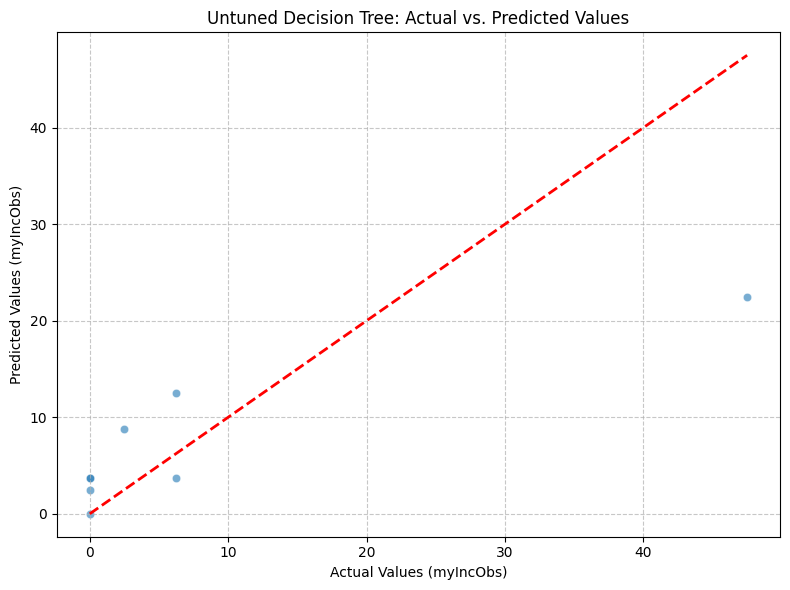

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_dt, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Ideal line
plt.xlabel('Actual Values (myIncObs)')
plt.ylabel('Predicted Values (myIncObs)')
plt.title('Untuned Decision Tree: Actual vs. Predicted Values')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Residual Plot for Untuned Decision Tree
A residual plot helps to identify if the model's errors are randomly distributed or if there's a pattern. This helps assess if the untuned Decision Tree is capturing all the information in the data.

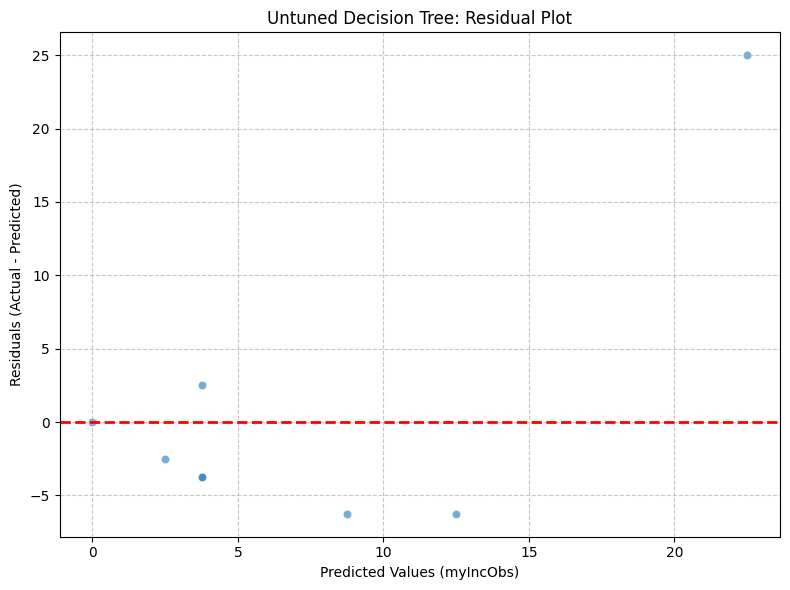

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

residuals_dt = y_test - y_pred_dt

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred_dt, y=residuals_dt, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', lw=2) # Zero residual line
plt.xlabel('Predicted Values (myIncObs)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Untuned Decision Tree: Residual Plot')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Decision Tree Structure Visualization
Visualizing the decision tree explicitly shows the features and thresholds used by the model to make predictions. This helps in understanding the model's logic.

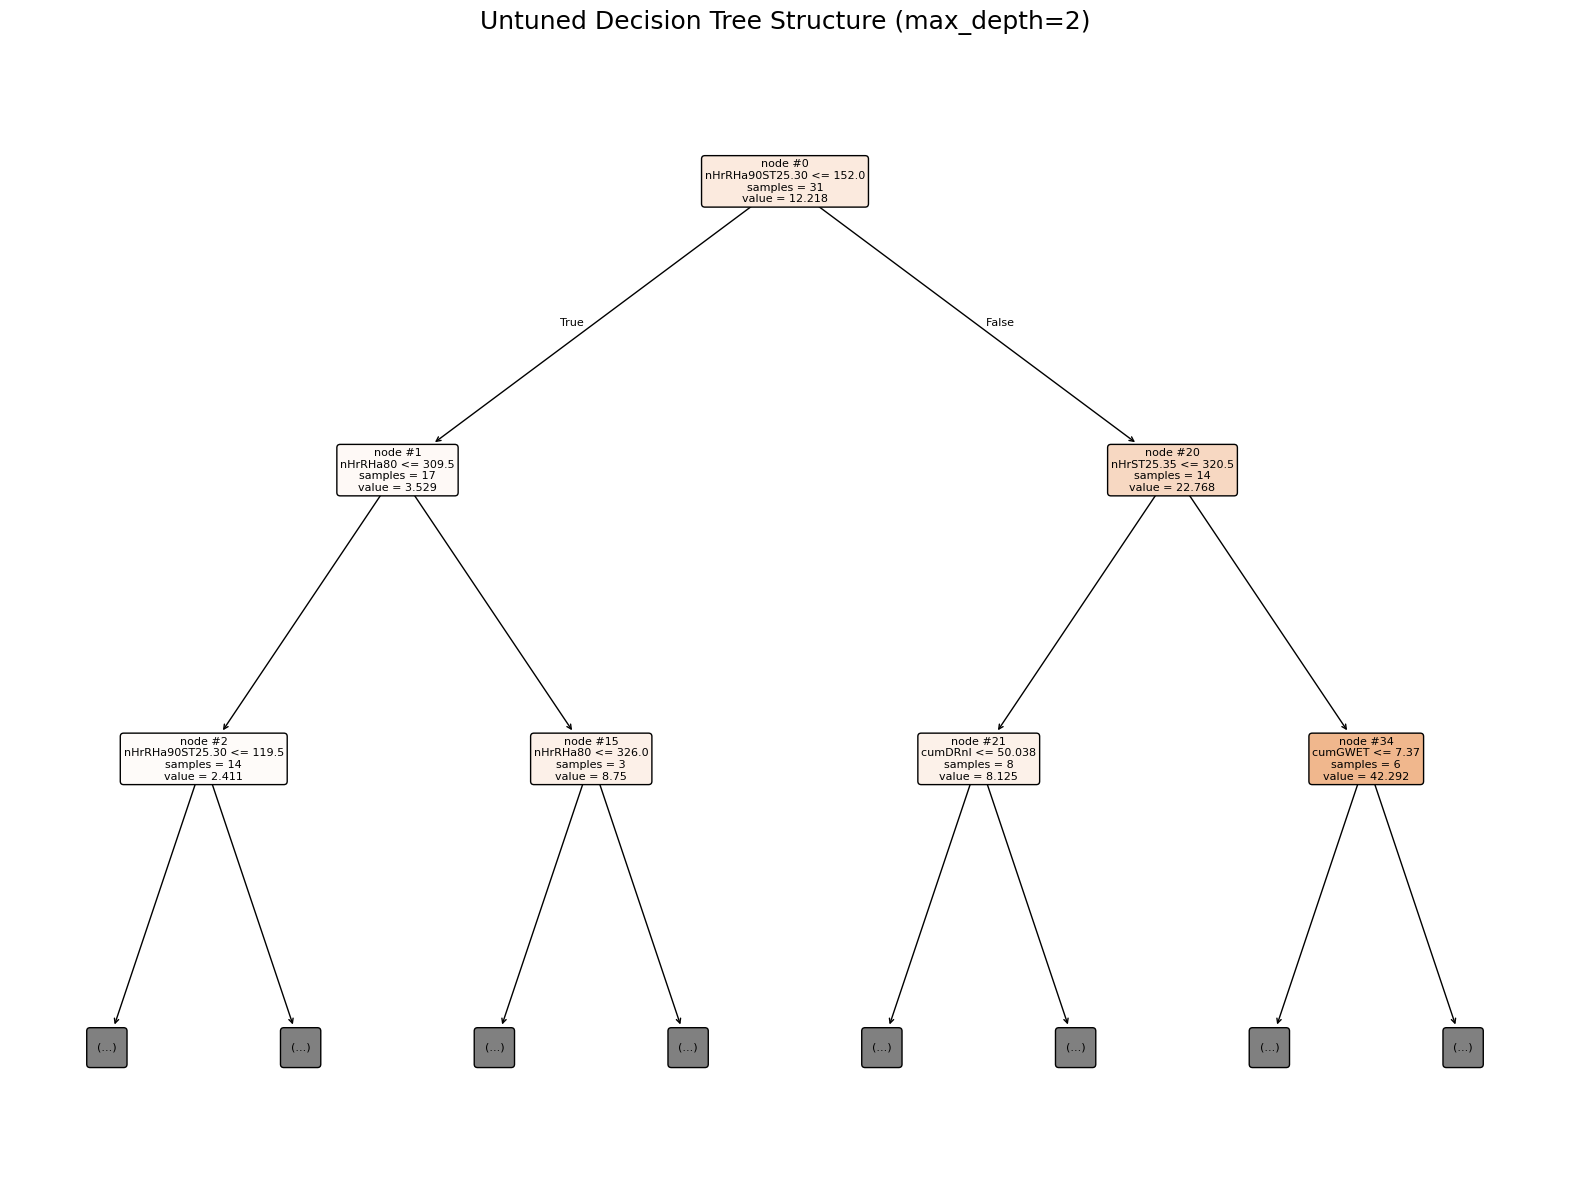

In [40]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 15))
plot_tree(dt_model,
          feature_names=X.columns.tolist(),
          filled=True,
          rounded=True,
          fontsize=8,
          max_depth=2, # Limit depth for readability
          impurity=False, # Do not show impurity for cleaner visualization
          node_ids=True # Show node IDs
         )
plt.title('Untuned Decision Tree Structure (max_depth=2)', fontsize=18)
plt.show()

### Interpreting Key Decision Rules from the Untuned Decision Tree

The Decision Tree visualization shows how the model makes predictions by splitting the data based on feature values. Each node in the tree represents a decision rule.

**`nHrST25.35`** (number of hours with soil temperature between 25 and 35°C) and **`nHrRHa90ST25.30`** (number of hours with relative humidity above 90% and soil temperature between 25 and 30°C) are often at the top of the tree or appear prominently. This indicates they are crucial in determining `myIncObs`.

For example, a high value of `nHrST25.35` (e.g., above 300-400 hours, depending on the exact split) tends to lead to higher predicted `myIncObs`, while lower values might lead to further splits on other variables. Similarly, high `nHrRHa90ST25.30` values also generally correlate with higher disease incidence.

To get a more detailed view of specific rules:
*   **Follow a path from the root node to a leaf node.** Each split along the path represents a condition based on a feature. For instance, if `nHrST25.35 <= [some_threshold]` and then `nHrRHa90ST25.30 <= [another_threshold]`, you will arrive at a leaf node that predicts a certain `value` of `myIncObs`.
*   **The `value` in each leaf node** is the average `myIncObs` for the samples that satisfy all the conditions leading to that node.
*   **The `samples` in each node** show how many data points fall into that particular segment of the decision path.

This provides rule-based explanation for the model's predictions. If you want to explore the tree further, you can adjust the `max_depth` parameter in the `plot_tree` function.